# 8. Neural networks and deep learning

This week, we'll learn about neural nets and build a model for classifying images of clothes

## 8.1 Fashion classification

Dataset:
- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:
- https://cs231n.github.io/

## 8.2 TensoreFlow and Keras
- Installing TensoreFlow
- Loading images

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
from tensorflow import keras

In [4]:
tf.__version__

'2.20.0'

In [5]:
tf.config.optimizer.set_jit(False)

In [37]:
# List all GPUs with detailed info
gpus = tf.config.experimental.list_physical_devices('GPU')
for i, gpu in enumerate(gpus):
    print(f"GPU {i}: {gpu}")

GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [38]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 2130212891281854742
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 5714870272
locality {
  bus_id: 1
  links {
  }
}
incarnation: 17961913309264193316
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:08:00.0, compute capability: 8.9"
xla_global_id: 416903419
]


I0000 00:00:1763733066.470929   14740 gpu_device.cc:2020] Created device /device:GPU:0 with 5450 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:08:00.0, compute capability: 8.9


In [39]:
from tensorflow.keras.preprocessing.image import load_img

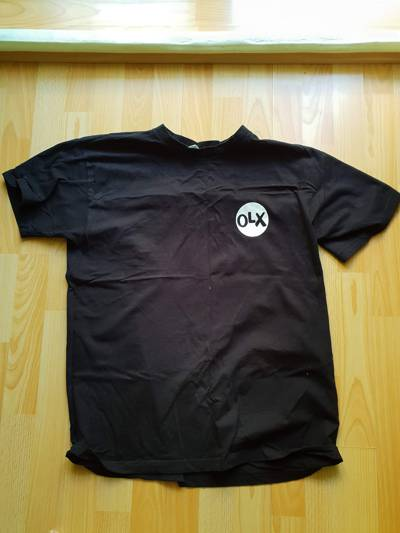

In [40]:
path = './data/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

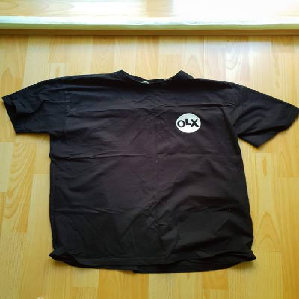

In [41]:
img = load_img(fullname, target_size=(299, 299))
img

In [42]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x78031C3622D0>


In [43]:
x = np.array(img)
x.shape

(299, 299, 3)

In [44]:
x

array([[[179, 171,  99],
        [179, 171,  99],
        [181, 173, 101],
        ...,
        [251, 253, 248],
        [251, 253, 248],
        [251, 254, 247]],

       [[188, 179, 112],
        [187, 178, 111],
        [186, 177, 108],
        ...,
        [251, 252, 247],
        [251, 252, 247],
        [251, 252, 246]],

       [[199, 189, 127],
        [200, 190, 128],
        [200, 191, 126],
        ...,
        [250, 251, 245],
        [250, 251, 245],
        [250, 251, 245]],

       ...,

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [183, 135,  25],
        [181, 133,  22],
        [183, 135,  24]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [182, 134,  23],
        [180, 132,  21],
        [182, 134,  23]],

       [[165, 151,  76],
        [173, 159,  84],
        [171, 157,  82],
        ...,
        [181, 133,  22],
        [179, 131,  20],
        [182, 134,  23]]

## 8.3 Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [45]:
from tensorflow.keras.applications.xception import Xception, preprocess_input, decode_predictions

In [46]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [47]:
X = np.array([x])

In [48]:
X.shape

(1, 299, 299, 3)

In [49]:
X = preprocess_input(X)

In [50]:
X[0]

array([[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.4039216 ,  0.3411765 , -0.2235294 ],
        [ 0.41960788,  0.35686278, -0.20784312],
        ...,
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.9843137 ,  0.94509804],
        [ 0.96862745,  0.99215686,  0.9372549 ]],

       [[ 0.47450984,  0.4039216 , -0.12156862],
        [ 0.4666667 ,  0.39607847, -0.12941176],
        [ 0.45882356,  0.38823533, -0.15294117],
        ...,
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.9372549 ],
        [ 0.96862745,  0.9764706 ,  0.92941177]],

       [[ 0.56078434,  0.48235297, -0.00392157],
        [ 0.5686275 ,  0.4901961 ,  0.00392163],
        [ 0.5686275 ,  0.49803925, -0.01176471],
        ...,
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863],
        [ 0.9607843 ,  0.96862745,  0.92156863]],

       ...,

       [[ 0.2941177 ,  0.18431377, -0.40392154],
        [ 0

In [51]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [52]:
pred

array([[3.24181776e-04, 1.57528528e-04, 2.14053754e-04, 1.52715074e-04,
        2.48151278e-04, 3.05355468e-04, 3.20901687e-04, 1.47656028e-04,
        2.04101190e-04, 1.49559070e-04, 1.95948538e-04, 2.10553553e-04,
        7.60363910e-05, 1.14132490e-04, 1.62806391e-04, 2.04759766e-04,
        1.97545465e-04, 1.44360674e-04, 1.40243792e-04, 1.73879802e-04,
        7.47440266e-04, 2.57285923e-04, 2.66943913e-04, 2.96924991e-04,
        3.73750256e-04, 2.77661253e-04, 2.16793313e-04, 2.27143275e-04,
        3.81145597e-04, 1.72261643e-04, 3.05986294e-04, 1.96961744e-04,
        3.92688497e-04, 4.78529924e-04, 2.91930832e-04, 3.26112058e-04,
        1.47607032e-04, 1.62581404e-04, 2.12818617e-04, 1.34099668e-04,
        2.40527472e-04, 6.75456889e-04, 2.55205348e-04, 1.44582635e-04,
        4.12820984e-04, 2.04486947e-04, 3.03278386e-04, 1.49452258e-04,
        1.99962553e-04, 2.27214128e-04, 2.93706747e-04, 2.27635770e-04,
        6.37827208e-04, 7.83355499e-04, 2.49786361e-04, 4.055931

In [53]:
pred.shape

(1, 1000)

In [54]:
decode_predictions(pred)

[[('n03595614', 'jersey', np.float32(0.6815963)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03818666)),
  ('n04370456', 'sweatshirt', np.float32(0.034341224)),
  ('n03710637', 'maillot', np.float32(0.011393404)),
  ('n04525038', 'velvet', np.float32(0.0018493979))]]

## 8.4 Convolutional neural networks
- Types of layers: convolutional and dense
- Convolutional layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

## 8.5 Transfer learning
- Reading data with `ImageDataGenerator`
- Train `Xception` on smaller images (150x150)

(Better to run it with a GPU)

In [55]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [56]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './data/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [57]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [58]:
X, y = next(train_ds)

In [59]:
X

array([[[[ 0.05098045, -0.01176471, -0.17647058],
         [ 0.09019613,  0.02745104, -0.1372549 ],
         [ 0.10588241,  0.04313731, -0.12156862],
         ...,
         [ 0.6313726 ,  0.5921569 ,  0.4431373 ],
         [ 0.6313726 ,  0.5921569 ,  0.4431373 ],
         [ 0.6313726 ,  0.5921569 ,  0.4431373 ]],

        [[ 0.07450986,  0.01176476, -0.15294117],
         [ 0.082353  ,  0.0196079 , -0.14509803],
         [ 0.09019613,  0.02745104, -0.1372549 ],
         ...,
         [ 0.6627451 ,  0.62352943,  0.47450984],
         [ 0.6627451 ,  0.62352943,  0.47450984],
         [ 0.6627451 ,  0.62352943,  0.47450984]],

        [[ 0.082353  ,  0.0196079 , -0.14509803],
         [ 0.09019613,  0.02745104, -0.1372549 ],
         [ 0.09803927,  0.03529418, -0.12941176],
         ...,
         [ 0.67058825,  0.6313726 ,  0.48235297],
         [ 0.67058825,  0.6313726 ,  0.48235297],
         [ 0.67058825,  0.6313726 ,  0.48235297]],

        ...,

        [[-0.31764704, -0.36470586, -0

In [60]:
X.shape

(32, 150, 150, 3)

In [61]:
y[:5]

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [62]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './data/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


Version 1

In [63]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [64]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [65]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.6617 - loss: 1.3213 - val_accuracy: 0.7771 - val_loss: 0.8313
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8132 - loss: 0.5729 - val_accuracy: 0.7478 - val_loss: 0.8804
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8739 - loss: 0.3706 - val_accuracy: 0.7331 - val_loss: 1.0413
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8944 - loss: 0.2945 - val_accuracy: 0.7683 - val_loss: 1.0460
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9475 - loss: 0.1655 - val_accuracy: 0.7478 - val_loss: 1.0386
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9632 - loss: 0.1071 - val_accuracy: 0.8123 - val_loss: 0.9103
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9827 - loss: 0.0640 - val_accuracy: 0.8065 - val_loss: 0.9525
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9870 - loss: 0.0466 - val_accuracy: 0.7977 -

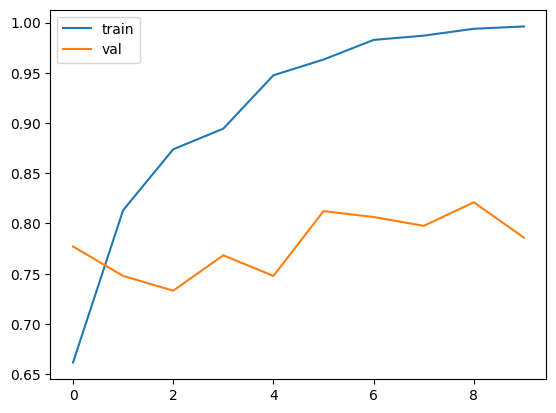

In [66]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
# plt.xticks(np.arange(10))
plt.legend()

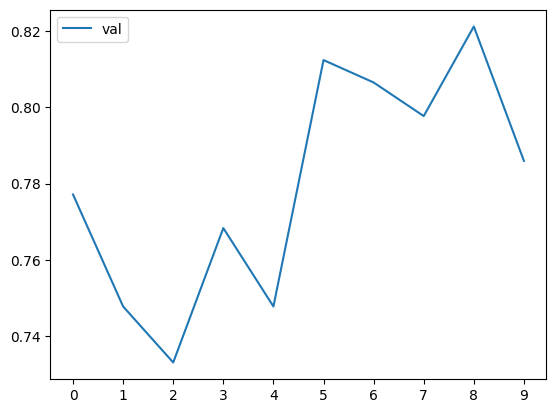

In [67]:
# plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()

## 8.6 Adjusting the learning rate
- What's the learning rate
- Trying different values

In [68]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [69]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.3377 - loss: 2.0153 - val_accuracy: 0.4663 - val_loss: 1.6601
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5437 - loss: 1.4306 - val_accuracy: 0.5806 - val_loss: 1.2899
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6359 - loss: 1.1685 - val_accuracy: 0.6510 - val_loss: 1.0980
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6809 - loss: 1.0182 - val_accuracy: 0.6921 - val_loss: 0.9848
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7083 - loss: 0.9211 - val_accuracy: 0.7155 - val_loss: 0.9037
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7269 - loss: 0.8496 - val_accuracy: 0.7214 - val_loss: 0.8522
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7451 - loss: 0.7947 - val_accuracy: 0.7566 - val_loss: 0.8105
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7604 - loss: 0.7498 - val_accuracy: 0

In [ ]:
# del scores[0.1]
# del scores[0.0001]

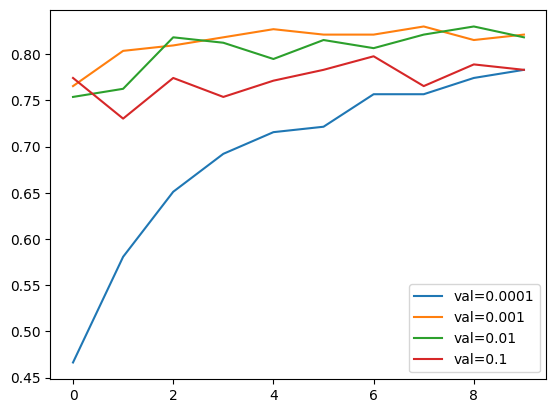

In [70]:
for lr, hist in scores.items():
    # plt.plot(hist['accuracy'], label=('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

# plt.xticks(np.arange(10))
plt.legend()

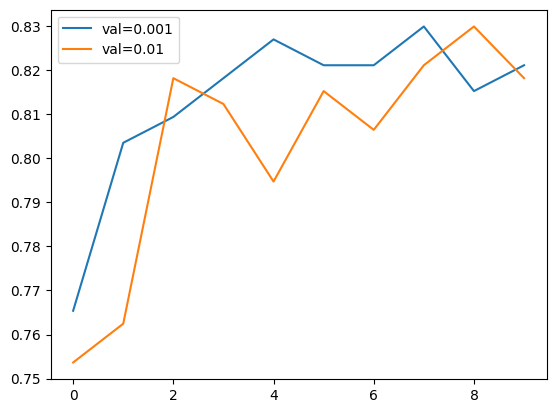

In [71]:
for lr, hist in scores.items():
    if lr in [0.01, 0.001]:  # Only plot these learning rates
        plt.plot(hist['val_accuracy'], label=('val=%s' % lr))
        
plt.legend()

In [72]:
learning_rate = 0.001

## 8.7 Checkpointing

`Def`: Checkpointing is a way to save our model after each iteration or when certain conditions are meet.

- Saving the best model only
- Training a model with callbacks

In [73]:
# model.save_weights('model_v1.h5', save_format='h5')
# model.save_weights('model_v1.h5')
model.save_weights('model_v1.weights.h5')

In [74]:
chechpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [75]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[chechpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4867 - loss: 1.4995

96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.6108 - loss: 1.1336 - val_accuracy: 0.7742 - val_loss: 0.7394
Epoch 2/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7747 - loss: 0.6766

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7849 - loss: 0.6426 - val_accuracy: 0.8065 - val_loss: 0.6279
Epoch 3/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8228 - loss: 0.5302

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8253 - loss: 0.5194 - val_accuracy: 0.8182 - val_loss: 0.5870
Epoch 4/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8680 - loss: 0.4291

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8605 - loss: 0.4350 - val_accuracy: 0.8328 - val_loss: 0.5461
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8810 - loss: 0.3779 - val_accuracy: 0.8123 - val_loss: 0.5389
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9097 - loss: 0.3298 - val_accuracy: 0.8182 - val_loss: 0.5361
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9192 - loss: 0.2905 - val_accuracy: 0.8211 - val_loss: 0.5383
Epoch 8/10
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9362 - loss: 0.2551

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9312 - loss: 0.2643 - val_accuracy: 0.8387 - val_loss: 0.5279
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9397 - loss: 0.2366 - val_accuracy: 0.8270 - val_loss: 0.5261
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9492 - loss: 0.2162 - val_accuracy: 0.8358 - val_loss: 0.5216


## 8.8 Adding more layers

- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [76]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(10)(inner)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [77]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.5417 - loss: 1.4194 - val_accuracy: 0.6686 - val_loss: 1.0166
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7239 - loss: 0.8301 - val_accuracy: 0.7801 - val_loss: 0.7609
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8087 - loss: 0.6042 - val_accuracy: 0.7889 - val_loss: 0.6660
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8416 - loss: 0.4816 - val_accuracy: 0.7889 - val_loss: 0.6120
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8778 - loss: 0.3985 - val_accuracy: 0.8035 - val_loss: 0.5768
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8980 - loss: 0.3418 - val_accuracy: 0.7977 - val_loss: 0.5825
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9143 - loss: 0.2953 - val_accuracy: 0.8035 - val_loss: 0.5488
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9342 - loss: 0.2502 - val_accuracy: 0.818

2025-11-21 16:06:10.029099: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-21 16:06:10.661456: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 68 bytes spill stores, 68 bytes spill loads



96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.6783 - loss: 0.9362 - val_accuracy: 0.7859 - val_loss: 0.6703
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8253 - loss: 0.4941 - val_accuracy: 0.8123 - val_loss: 0.5746
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8908 - loss: 0.3343 - val_accuracy: 0.8270 - val_loss: 0.5293
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9293 - loss: 0.2354 - val_accuracy: 0.7947 - val_loss: 0.5760
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9606 - loss: 0.1623 - val_accuracy: 0.8094 - val_loss: 0.5773
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9681 - loss: 0.1274 - val_accuracy: 0.8299 - val_loss: 0.5731
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9896 - loss: 0.0788 - val_accuracy: 0.8270 - val_loss: 0.6210
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9925 - loss: 0.0618 - val_accuracy: 0.8094 - val_loss: 

2025-11-21 16:06:52.308109: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-21 16:06:52.831453: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3793', 24 bytes spill stores, 24 bytes spill loads

2025-11-21 16:06:53.407866: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 68 bytes spill stores, 68 bytes spill loads



11/96 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3868 - loss: 1.9290

2025-11-21 16:06:57.020456: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3793', 48 bytes spill stores, 48 bytes spill loads

2025-11-21 16:06:57.030914: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3800', 4 bytes spill stores, 4 bytes spill loads

2025-11-21 16:06:57.156202: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3800', 8 bytes spill stores, 8 bytes spill loads

2025-11-21 16:06:57.233654: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3800', 68 bytes spill stores, 68 bytes spill loads

2025-11-21 16:06:57.289658: I external/local

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5995 - loss: 1.2709

2025-11-21 16:07:05.698923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1093', 4 bytes spill stores, 4 bytes spill loads

2025-11-21 16:07:05.923171: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1093', 8 bytes spill stores, 8 bytes spill loads

2025-11-21 16:07:05.931218: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1086', 48 bytes spill stores, 48 bytes spill loads

2025-11-21 16:07:06.039229: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1093', 68 bytes spill stores, 68 bytes spill loads

2025-11-21 16:07:06.094338: I external/local

96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.6776 - loss: 0.9717 - val_accuracy: 0.7977 - val_loss: 0.6693
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8462 - loss: 0.4395 - val_accuracy: 0.8094 - val_loss: 0.5553
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9117 - loss: 0.2697 - val_accuracy: 0.8240 - val_loss: 0.5616
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9537 - loss: 0.1584 - val_accuracy: 0.8065 - val_loss: 0.5875
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9710 - loss: 0.0954 - val_accuracy: 0.8065 - val_loss: 0.6426
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9902 - loss: 0.0518 - val_accuracy: 0.8387 - val_loss: 0.6386
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9987 - loss: 0.0226 - val_accuracy: 0.8211 - val_loss: 0.6465
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9993 - loss: 0.0142 - val_accuracy: 0.8211 - val_loss: 

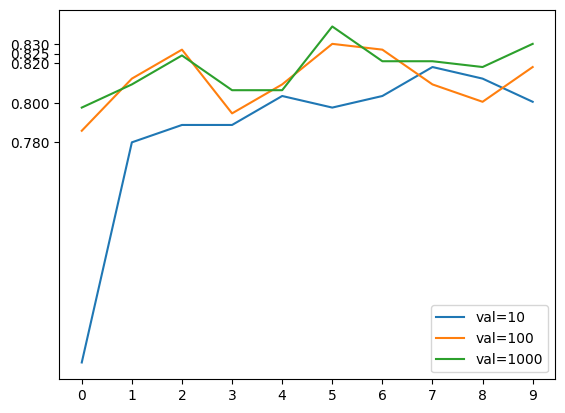

In [78]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

## 8.9 Regularization and dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [79]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [80]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.6842 - loss: 0.9656 - val_accuracy: 0.7537 - val_loss: 0.7140
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8152 - loss: 0.5194 - val_accuracy: 0.7947 - val_loss: 0.5958
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8869 - loss: 0.3505 - val_accuracy: 0.8211 - val_loss: 0.5568
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9267 - loss: 0.2474 - val_accuracy: 0.8152 - val_loss: 0.5426
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9544 - loss: 0.1701 - val_accuracy: 0.8182 - val_loss: 0.5636
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9681 - loss: 0.1244 - val_accuracy: 0.8094 - val_loss: 0.5795
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9876 - loss: 0.0794 - val_accuracy: 0.8358 - val_loss: 0.5856
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9896 - loss: 0.0648 - val_accuracy: 0.82

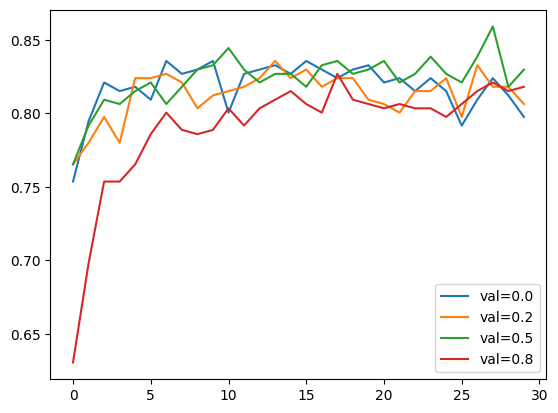

In [81]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

# plt.ylim(0.78, 0.86)
plt.legend()

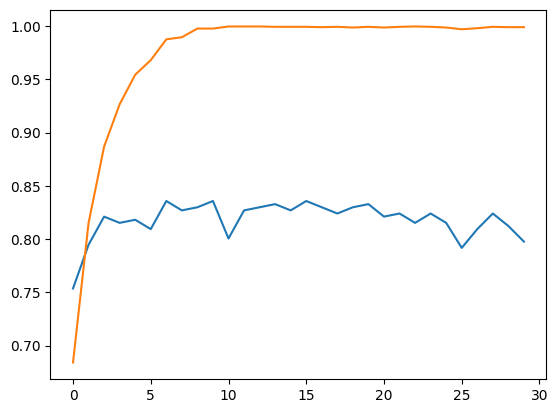

In [82]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label=0.0)
plt.plot(hist['accuracy'], label=('val=%s' % droprate))

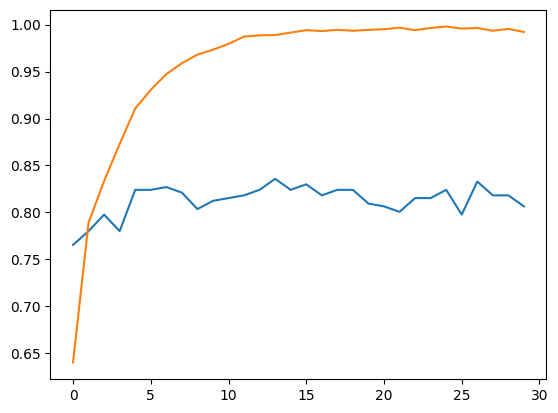

In [88]:
hist = scores[0.2]
plt.plot(hist['val_accuracy'], label=0.2)
plt.plot(hist['accuracy'], label=('val=%s' % droprate))

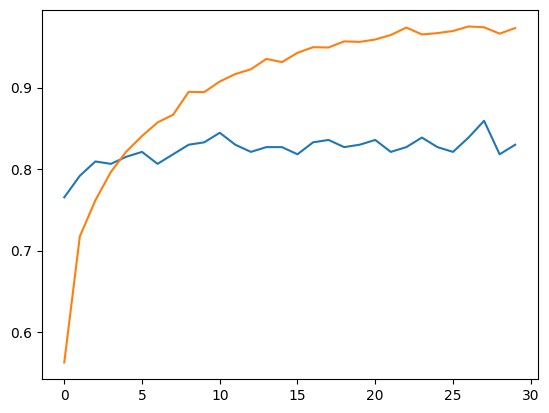

In [87]:
hist = scores[0.5]
plt.plot(hist['val_accuracy'], label=0.5)
plt.plot(hist['accuracy'], label=('val=%s' % droprate))

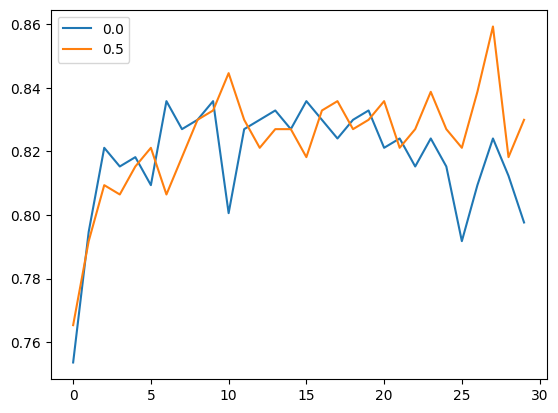

In [90]:
hist = scores[0.0]
plt.plot(hist['val_accuracy'], label=0.0)

# hist = scores[0.2]
# plt.plot(hist['val_accuracy'], label=0.2)

hist = scores[0.5]
plt.plot(hist['val_accuracy'], label=0.5)

plt.legend()

## 8.10 Data augmentation

- Different data augmentations
- Training a model with augmentations
- How to select data augmentations?

In [91]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    # shear_ranege=1.0,
    # zoom_range=0.1,
    # vertical_flip=True,
)

train_ds = train_gen.flow_from_directory(
    './data/train',
    target_size=(150, 150),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './data/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [92]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.6525 - loss: 1.0308 - val_accuracy: 0.7537 - val_loss: 0.6873
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7787 - loss: 0.6167 - val_accuracy: 0.7859 - val_loss: 0.6352
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8390 - loss: 0.4680 - val_accuracy: 0.7859 - val_loss: 0.5965
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8735 - loss: 0.3706 - val_accuracy: 0.8065 - val_loss: 0.5733
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9058 - loss: 0.2857 - val_accuracy: 0.8182 - val_loss: 0.6060
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9329 - loss: 0.2233 - val_accuracy: 0.8035 - val_loss: 0.5922
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9443 - loss: 0.1754 - val_accuracy: 0.8299 - val_loss: 0.5319
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9537 - loss: 0.1517 - val_accuracy: 0.8182 -

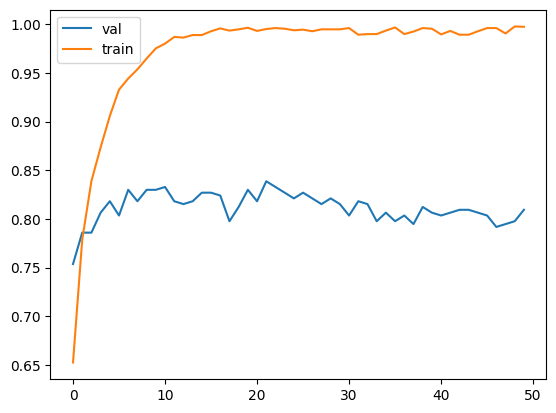

In [93]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

In [94]:
learning_rate = 0.001
size = 100
droprate = 0.5

model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.5675 - loss: 1.3133 - val_accuracy: 0.7683 - val_loss: 0.7575
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7158 - loss: 0.8330 - val_accuracy: 0.8123 - val_loss: 0.6173
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7608 - loss: 0.6916 - val_accuracy: 0.7859 - val_loss: 0.6369
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7953 - loss: 0.5851 - val_accuracy: 0.8211 - val_loss: 0.5480
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8171 - loss: 0.5208 - val_accuracy: 0.8182 - val_loss: 0.5577
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8331 - loss: 0.4705 - val_accuracy: 0.8152 - val_loss: 0.5353
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8621 - loss: 0.4059 - val_accuracy: 0.8211 - val_loss: 0.5526
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8693 - loss: 0.3665 - val_accuracy: 0.8211 -

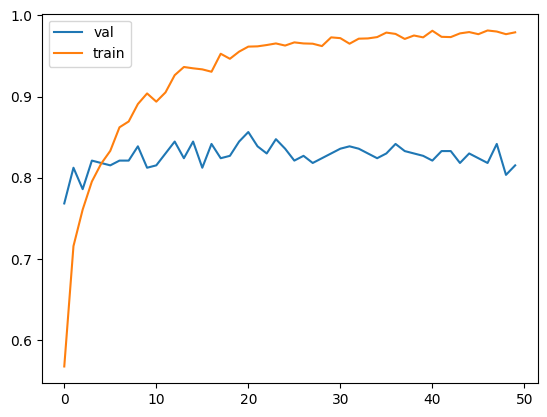

In [95]:
hist = history.history
plt.plot(hist['val_accuracy'], label='val')
plt.plot(hist['accuracy'], label='train')

plt.legend()

## 8.11 Training a larger model

- Train a 299x299 model

In [96]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [97]:
input_size = 299

In [99]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    './data/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    './data/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [100]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [101]:
learning_rate = 0.0005
size = 100
droprate = 0.5

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50


2025-11-21 16:27:09.809320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:09.917700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:11.729477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:11.874240: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:14.355214: E external/local_xla/xla/stream_

54/96 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.4340 - loss: 1.7638

2025-11-21 16:27:45.379752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:45.484003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:47.063164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:47.204175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:27:49.673035: E external/local_xla/xla/stream_

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.5062 - loss: 1.5501

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 309ms/step - accuracy: 0.7881 - loss: 0.6477 - val_accuracy: 0.8416 - val_loss: 0.5054
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.8141 - loss: 0.5654

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 313ms/step - accuracy: 0.8178 - loss: 0.5626 - val_accuracy: 0.8563 - val_loss: 0.4555
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 306ms/step - accuracy: 0.8351 - loss: 0.4945 - val_accuracy: 0.8328 - val_loss: 0.4440
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.8454 - loss: 0.4592

96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 306ms/step - accuracy: 0.8435 - loss: 0.4607 - val_accuracy: 0.8827 - val_loss: 0.4112
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.8608 - loss: 0.4217 - val_accuracy: 0.8651 - val_loss: 0.3935
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.8654 - loss: 0.3986 - val_accuracy: 0.8710 - val_loss: 0.4015
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.8735 - loss: 0.3737 - val_accuracy: 0.8680 - val_loss: 0.3870
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step - accuracy: 0.8774 - loss: 0.3505 - val_accuracy: 0.8622 - val_loss: 0.3928
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.8911 - loss: 0.3331 - val_accuracy: 0.8710 - val_loss: 0.3779
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 303ms/step - accuracy: 0.8882 - loss: 0.3285 - val_accuracy: 0.8534 - val_loss: 0.3725
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.8970 - loss: 0.2977 - val_accuracy: 0.

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 313ms/step - accuracy: 0.9172 - loss: 0.2516 - val_accuracy: 0.8856 - val_loss: 0.3643
Epoch 18/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step - accuracy: 0.9162 - loss: 0.2499 - val_accuracy: 0.8592 - val_loss: 0.3823
Epoch 19/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 309ms/step - accuracy: 0.9218 - loss: 0.2242 - val_accuracy: 0.8710 - val_loss: 0.3363
Epoch 20/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.9198 - loss: 0.2267 - val_accuracy: 0.8680 - val_loss: 0.3660
Epoch 21/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 309ms/step - accuracy: 0.9263 - loss: 0.2174 - val_accuracy: 0.8739 - val_loss: 0.3682
Epoch 22/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.9293 - loss: 0.2092 - val_accuracy: 0.8856 - val_loss: 0.3819
Epoch 23/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.9312 - loss: 0.2011 - val_accuracy: 0.8768 - val_loss: 0.3620
Epoch 24/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 300ms/step - accuracy: 0.9299 - loss: 0.2011 - val_accuracy

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step - accuracy: 0.9397 - loss: 0.1640 - val_accuracy: 0.8886 - val_loss: 0.3547
Epoch 32/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.9417 - loss: 0.1597 - val_accuracy: 0.8739 - val_loss: 0.4010
Epoch 33/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 297ms/step - accuracy: 0.9514 - loss: 0.1438 - val_accuracy: 0.8680 - val_loss: 0.3577
Epoch 34/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.9527 - loss: 0.1482 - val_accuracy: 0.8680 - val_loss: 0.4096
Epoch 35/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.9508 - loss: 0.1480 - val_accuracy: 0.8680 - val_loss: 0.3786
Epoch 36/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 303ms/step - accuracy: 0.9550 - loss: 0.1391 - val_accuracy: 0.8827 - val_loss: 0.3695
Epoch 37/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - accuracy: 0.9544 - loss: 0.1385 - val_accuracy: 0.8563 - val_loss: 0.3856
Epoch 38/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 307ms/step - accuracy: 0.9602 - loss: 0.1259 - val_accuracy

## 8.12 Using the model

- Loading the model
- Evaluating the model
- Getting predictions

In [102]:
import tensorflow as tf
from tensorflow import keras

In [103]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

In [104]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './data/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 372 images belonging to 10 classes.


In [106]:
model = keras.models.load_model('xception_v4_1_31_0.889.h5')

In [107]:
model.evaluate(test_ds)

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8931 - loss: 0.2867

2025-11-21 16:55:05.862676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:55:05.962860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:55:07.281667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:55:07.411904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-21 16:55:09.502718: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9113 - loss: 0.2470 


[0.24695250391960144, 0.9112903475761414]

In [108]:
path = 'data/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'

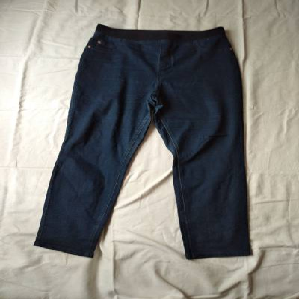

In [110]:
img = load_img(path, target_size=(299, 299))
img

In [111]:
import numpy as np

In [112]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [113]:
X = preprocess_input(X)

In [114]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [115]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [116]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-4.684937),
 'hat': np.float32(-8.511776),
 'longsleeve': np.float32(-2.3115926),
 'outwear': np.float32(-2.5894163),
 'pants': np.float32(11.135444),
 'shirt': np.float32(-2.0602343),
 'shoes': np.float32(-7.0281315),
 'shorts': np.float32(4.0425544),
 'skirt': np.float32(-5.734417),
 't-shirt': np.float32(-4.732364)}

## 8.13 Summary
- We can use pre-trained models for general image classification
- Convolutional layers let us turn an image into a vector
- Dense layers use the vector to make the predictions
- Instead of training a model from scratch, we can use transfer learning and re-use already trained convolutional layers
- First, train a small model (150x150) before training a big one (299x299)
- Learning rate - how fast the model trians. Fast learners aren't always best ones
- We can save the best model using callbacks and checkpointing
- To avoid overfitting, use dropout and augmentation

## 8.14 Explore more
- Add more data, e.g. Zalando, etc (ADD LINKS)
- Albumentations - another way of generating augmentations
- Use PyTorch or MXNet instead of TensorFlow/Keras
- In addition to Xception, there are others architectures - try them

Other projects:
- cats vs dogs
- Hotdog vs not hotdog
- Category of images